## This just tests the non-dimensionalized direct integration of the SDE for x(t)

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

In [2]:
# ----------------------------
# 1. Define Parameters
# ----------------------------

# System Physical Parameters
M = 1.0                # Mass (arbitrary units)
w_0 = 1.0             # Natural frequency (rad/s)
Qual = 100.0         # Quality factor of the oscillator
gamma = -0.06       # Nonlinearity coefficient (Duffing term)
GAMMA = w_0/(2*Qual)

# Driving Forces Parameters
w_p = 2*w_0           # Parametric driving frequency (rad/s), set to 2*w_0 for parametric resonance
dw = w_p/2 - w_0
F_p = 2*w_p*GAMMA       # Amplitude of parametric driving
F_p = F_p*1.01
F = 0.00              # Amplitude of direct driving
w_F = w_0            # Frequency of direct driving (rad/s)

# Thermal Parameters
k_B = 1.0            # Boltzmann's constant (arbitrary units)
T = 0.3*0            # Temperature (K) - currently set to 0

# Time and Simulation Parameters
period = 2*jnp.pi/w_0        # Natural period of oscillation
t0 = 0.0                     # Start time
num_periods = 5000            # Number of periods to simulate
t1 = num_periods*period      # End time
dt0 = period/1000           # Initial time step
num_pts_per_period = 100    # Number of points per period
ts_dim = jnp.linspace(t0, t1, num_periods*num_pts_per_period)

# Initial Conditions
x0 = 0.3                  # Initial displacement
v0 = 0.0                    # Initial velocity
y0_x = jnp.array([x0, v0])  # Initial state vector [position, velocity]

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
def Hamiltonian(t,Q, P):
    return 3*gamma/(32*w_0) * (Q**2 + P**2)**2 + dw/2 *(Q**2 - P**2) +  F_p/(8*M*w_0) * (P**2 - Q**2) - F*Q/(2*M*w_0)

In [4]:
def Potential_slow_var(X):
    return 1/2*(GAMMA - F_p/(2*w_p)*jnp.sqrt( 1-(2*dw/F_p)**2 ) )*X**2 - 1/4*3*gamma/(4*w_p)*X**4

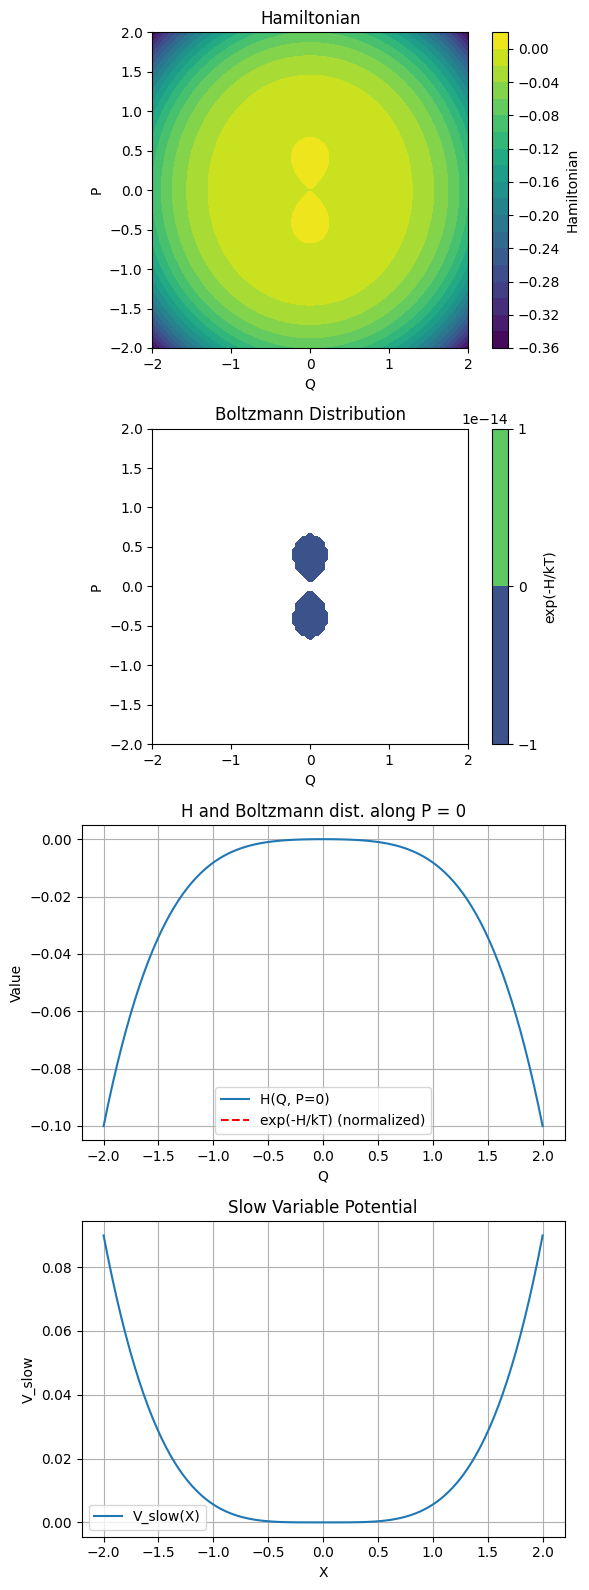

In [5]:
# Plot the Hamiltonian, Boltzmann distribution, and Slow Potential
Q_range = jnp.linspace(-2, 2, 100)
P_range = jnp.linspace(-2, 2, 100)
# Create meshgrid for Q and P
Q_mesh, P_mesh = jnp.meshgrid(Q_range, P_range)

# Vectorize Hamiltonian over both Q and P meshgrids
H_values = jax.vmap(lambda q, p: jax.vmap(lambda qi, pi: Hamiltonian(0.,qi, pi))(q, p))(Q_mesh, P_mesh)

# Calculate Boltzmann distribution
boltz_values = jnp.exp(-H_values/(k_B * T))

# Create figure with four subplots
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(6, 16))

# Create Hamiltonian contour plot
contour1 = ax1.contourf(Q_range, P_range, H_values, levels=20, cmap='viridis')
plt.colorbar(contour1, ax=ax1, label='Hamiltonian')
ax1.set_aspect('equal')
ax1.set_xlabel('Q')
ax1.set_ylabel('P')
ax1.set_title('Hamiltonian')

# Create Boltzmann distribution contour plot
contour2 = ax2.contourf(Q_range, P_range, boltz_values, levels=20, cmap='viridis')
plt.colorbar(contour2, ax=ax2, label='exp(-H/kT)')
ax2.set_aspect('equal')
ax2.set_xlabel('Q')
ax2.set_ylabel('P')
ax2.set_title('Boltzmann Distribution')

# Plot P = 0 line for both
H_P0 = jnp.array([Hamiltonian(0., q, 0.) for q in Q_range])
boltz_P0 = jnp.exp(-H_P0/(k_B * T))

ax3.plot(Q_range, H_P0, label='H(Q, P=0)')
ax3.plot(Q_range, boltz_P0/jnp.max(boltz_P0), '--', label='exp(-H/kT) (normalized)', color='red')
ax3.set_xlabel('Q')
ax3.set_ylabel('Value')
ax3.set_title('H and Boltzmann dist. along P = 0')
ax3.grid(True)
ax3.legend()

# Add plot for slow potential
V_slow = jnp.array([Potential_slow_var(x) for x in Q_range])
ax4.plot(Q_range, V_slow, label='V_slow(X)')
ax4.set_xlabel('X')
ax4.set_ylabel('V_slow')
ax4.set_title('Slow Variable Potential')
ax4.grid(True)
ax4.legend()

plt.tight_layout()
plt.show()

In [6]:
# ----------------------------
# 2. Define SDEs
# ----------------------------

# 2.1. Direct Integration SDE for x(t)
def drift_x_fn(t, state, args):
    """
    Drift function for the direct integration of x(t).
    y = [x, v]
    """
    x, v = state
    dxdt = v
    dvdt =  -2*w_0/(2*Qual) * v -  (w_0**2 -F_p/M * jnp.cos(w_p * t)) * x - gamma * x**3 + F*jnp.cos(w_F * t)/M
    return jnp.array([dxdt, dvdt])

def diffusion_x_fn(t, state, args):
    """
    Diffusion 
    """
    noise_strength =  jnp.sqrt(4*(w_0/(2*Qual))*k_B * T/M)  
    noise_matrix = jnp.zeros((2, 2))
    noise_matrix = noise_matrix.at[1, 1].set(noise_strength)
    return noise_matrix

w_shape = (2,)  # state is (x1, p1)
brownian_motion = diffrax.VirtualBrownianTree(
    t0, t1, 1.e-11, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)
terms_x = MultiTerm(ODETerm(drift_x_fn), ControlTerm(diffusion_x_fn, brownian_motion))
saveat = diffrax.SaveAt(ts=ts_dim)


# sample 1000 points
solution_x = diffrax.diffeqsolve(
    terms_x,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_x,
    args=(),
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=1000000000,
    stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),  # Enable adaptive stepping
)
sde_samples_x = solution_x.ys

/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

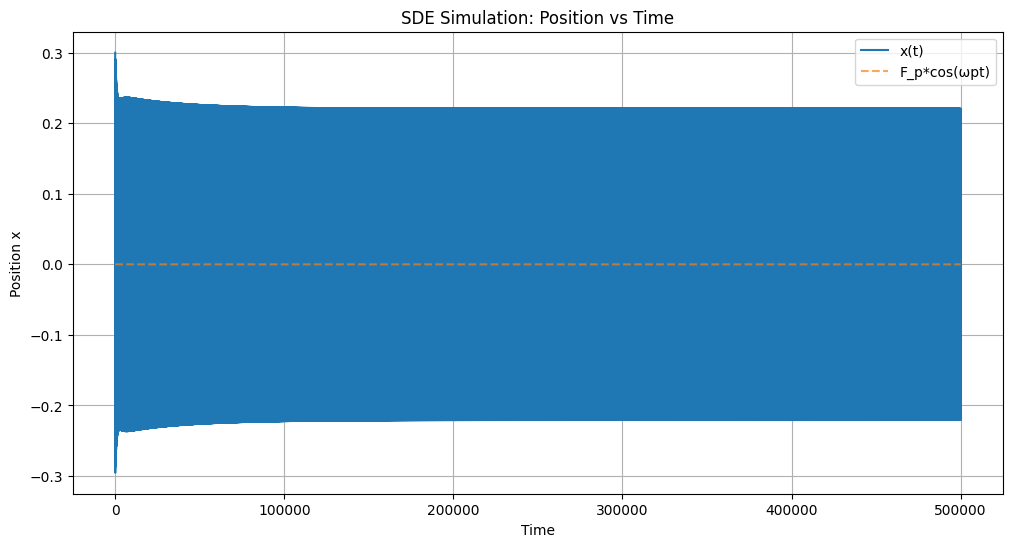

In [7]:
plt.figure(figsize=(12,  6))
plt.plot(sde_samples_x[:, 0], label='x(t)')
plt.plot(4 * 1e-8 * jnp.cos(w_0 * ts_dim), '--', label='F_p*cos(ωpt)', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Position x')
plt.title('SDE Simulation: Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

In [8]:
# # Amplitude Equations SDEs for RWA
def drift_QP_fn(t, state, args):
    """
    Drift function 
    """
    Q, P = state
        
    H = lambda _Q, _P: Hamiltonian(t,_Q, _P)
    
    dQdt =  jax.grad(H, 1)(Q, P) - w_0/(2*Qual)*Q
    dPdt = -jax.grad(H, 0)(Q, P) - w_0/(2*Qual)*P
    
    # Drift terms
    return jnp.array([dQdt, dPdt])



def diffusion_QP_fn(t, state, args):
    """
    Diffusion matrix for Q and P equations.
    Returns a 2x2 matrix where diagonal terms represent independent noise for Q and P.
    """
    noise_strength_QP =  jnp.sqrt(2*(w_0/(2*Qual))*k_B * T/(M*w_0**2))  
    return noise_strength_QP * jnp.eye(2) 


w_shape = (2,)  # state is (Q, P)
brownian_motion_QP = diffrax.VirtualBrownianTree(
    t0, t1, 1.e-11, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)

y0_QP = jnp.array([x0, 0.0])

terms_QP = MultiTerm(ODETerm(drift_QP_fn), ControlTerm(diffusion_QP_fn, brownian_motion_QP))

saveat = diffrax.SaveAt(ts=ts_dim)

solution_QP = diffrax.diffeqsolve(
    terms_QP,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_QP,
    args=(),
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=10000000000,
    stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),  # Enable adaptive stepping
)
sde_samples_QP = solution_QP.ys


100.00%|##########| [00:00<00:00, 4246.92%/s]


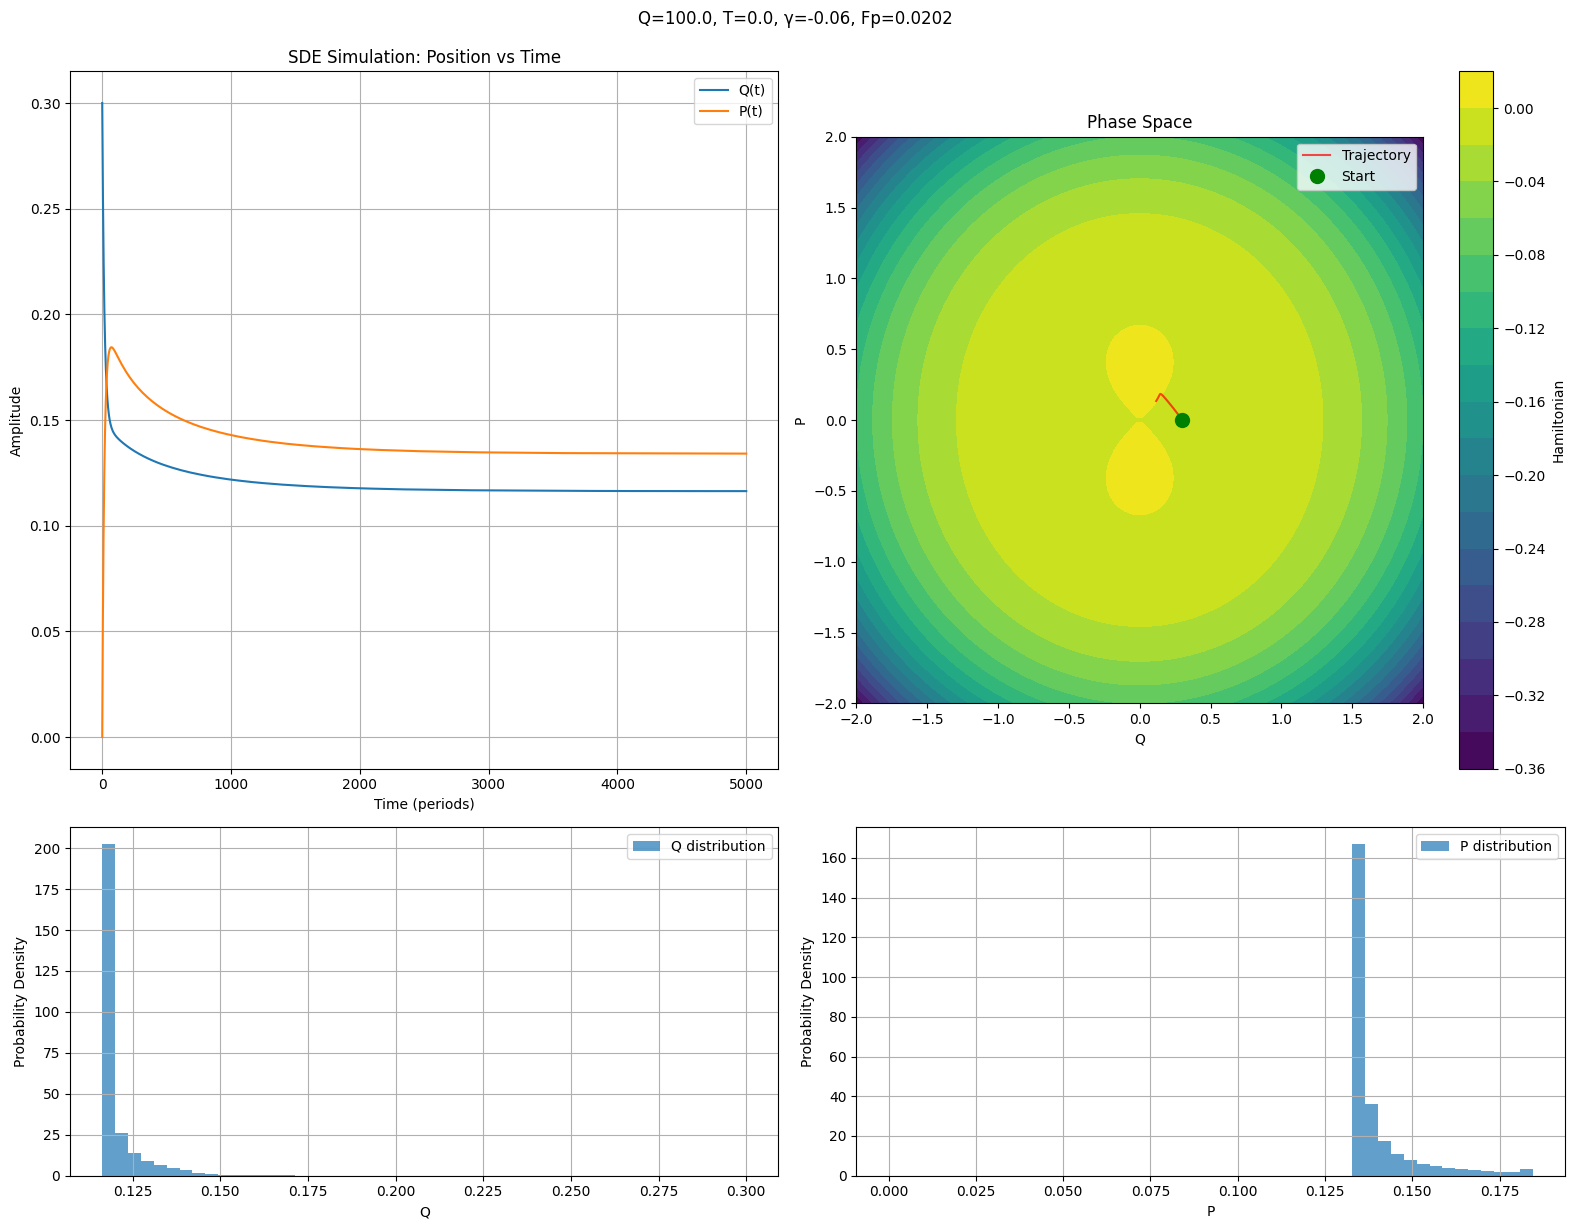

In [9]:
# Calculate the index for 20% of the data
cutoff_idx = int(len(ts_dim) )
# Create figure with a grid of subplots
fig = plt.figure(figsize=(16, 12))
gs = plt.GridSpec(2, 2, height_ratios=[2, 1])

# Top left: Q(t) and P(t) trajectories
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ts_dim[:cutoff_idx]/period, sde_samples_QP[:cutoff_idx, 0], label='Q(t)')
ax1.plot(ts_dim[:cutoff_idx]/period, sde_samples_QP[:cutoff_idx, 1], label='P(t)')
ax1.set_xlabel('Time (periods)')
ax1.set_ylabel('Amplitude')
ax1.set_title('SDE Simulation: Position vs Time')
ax1.grid(True)
ax1.legend()

# Top right: Phase space with Hamiltonian contour
ax2 = fig.add_subplot(gs[0, 1])
contour = ax2.contourf(Q_range, P_range, H_values, levels=20, cmap='viridis')
plt.colorbar(contour, ax=ax2, label='Hamiltonian')
ax2.plot(sde_samples_QP[:, 0], sde_samples_QP[:, 1], 'r-', label='Trajectory', alpha=0.7)
ax2.plot(sde_samples_QP[0, 0], sde_samples_QP[0, 1], 'go', label='Start', markersize=10)
ax2.set_aspect('equal')
ax2.set_xlabel('Q')
ax2.set_ylabel('P')
ax2.set_title('Phase Space')
ax2.legend()

# Bottom left: Q histogram
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(sde_samples_QP[:, 0], bins=50, density=True, alpha=0.7, label='Q distribution')
ax3.set_xlabel('Q')
ax3.set_ylabel('Probability Density')
ax3.grid(True)
ax3.legend()

# Bottom right: P histogram
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(sde_samples_QP[:, 1], bins=50, density=True, alpha=0.7, label='P distribution')
ax4.set_xlabel('P')
ax4.set_ylabel('Probability Density')
ax4.grid(True)
ax4.legend()

plt.tight_layout()
# Add title with parameters
title = f'Q={Qual}, T={T}, γ={gamma}, Fp={F_p}'
plt.suptitle(title, y=1.02)

# Create filename with parameters
filename = f"Q{Qual}_T{T}_gamma{gamma}_Fp{F_p}.png"
save_path = f"out/p-bit/{filename}"

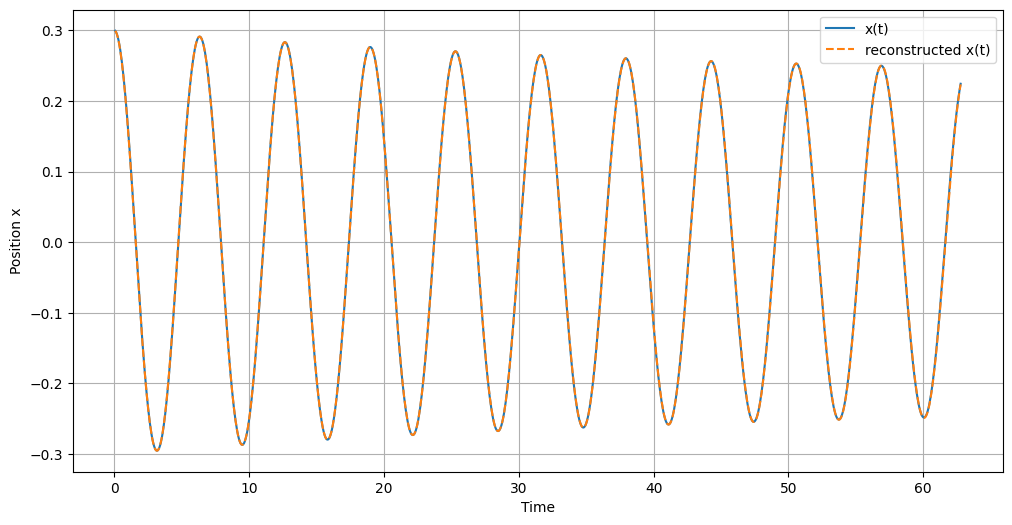

In [10]:
def reconstruct_x(t, Q, P):
    """
    Reconstruct x(t) from Q(t) and P(t).
    """
    return Q * jnp.cos(w_0 * t) + P * jnp.sin(w_0 * t)

id_start = 1
id_end = 1000


x_direct = sde_samples_x[id_start:id_end, 0]
x_reconstructed = reconstruct_x(ts_dim[id_start:id_end], sde_samples_QP[id_start:id_end, 0], sde_samples_QP[id_start:id_end  , 1])

plt.figure(figsize=(12, 6))
plt.plot(ts_dim[id_start:id_end],x_direct, label='x(t)')
plt.plot(ts_dim[id_start:id_end],x_reconstructed, '--', label='reconstructed x(t)')

plt.xlabel('Time')
plt.ylabel('Position x')
# plt.title(f'Reconstructed x(t) from Q(t) and P(t) - L2 Loss: {l2_diff:.6f}')
plt.grid(True)
plt.legend()
plt.show()

In [11]:
# Calculate alpha from the given equation
alpha = jnp.arcsin(jnp.sqrt(1 - 2*w_0*dw/F_p))/2

# 2.3. Slow Variable SDE
def drift_X_slow_fn(t, state, args):
    """
    Drift function for the slow variable X.
    The drift is the negative gradient of the potential.
    """
    X = state[0]  # state is [X]
    dXdt = -jax.grad(Potential_slow_var, 0)(X)
    return jnp.array([dXdt])

def diffusion_X_slow_fn(t, state, args):
    """
    Diffusion term for the slow variable X.
    """
    noise_strength = jnp.sqrt(2*k_B*T/(M*w_0))
    return jnp.array([[noise_strength]])

# Setup for slow variable integration
w_shape_slow = (1,)  # state is just X
brownian_motion_slow = diffrax.VirtualBrownianTree(
    t0, t1, 1.e-11, w_shape_slow, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)

y0_X_slow = jnp.array([x0*jnp.cos(alpha)])  # Initial condition for slow variable

terms_X_slow = MultiTerm(
    ODETerm(drift_X_slow_fn), 
    ControlTerm(diffusion_X_slow_fn, brownian_motion_slow)
)

# Solve the SDE for slow variable
solution_X_slow = diffrax.diffeqsolve(
    terms_X_slow,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_X_slow,
    args=(),
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=1000000000,
    stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
)
sde_samples_X_slow = solution_X_slow.ys

/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

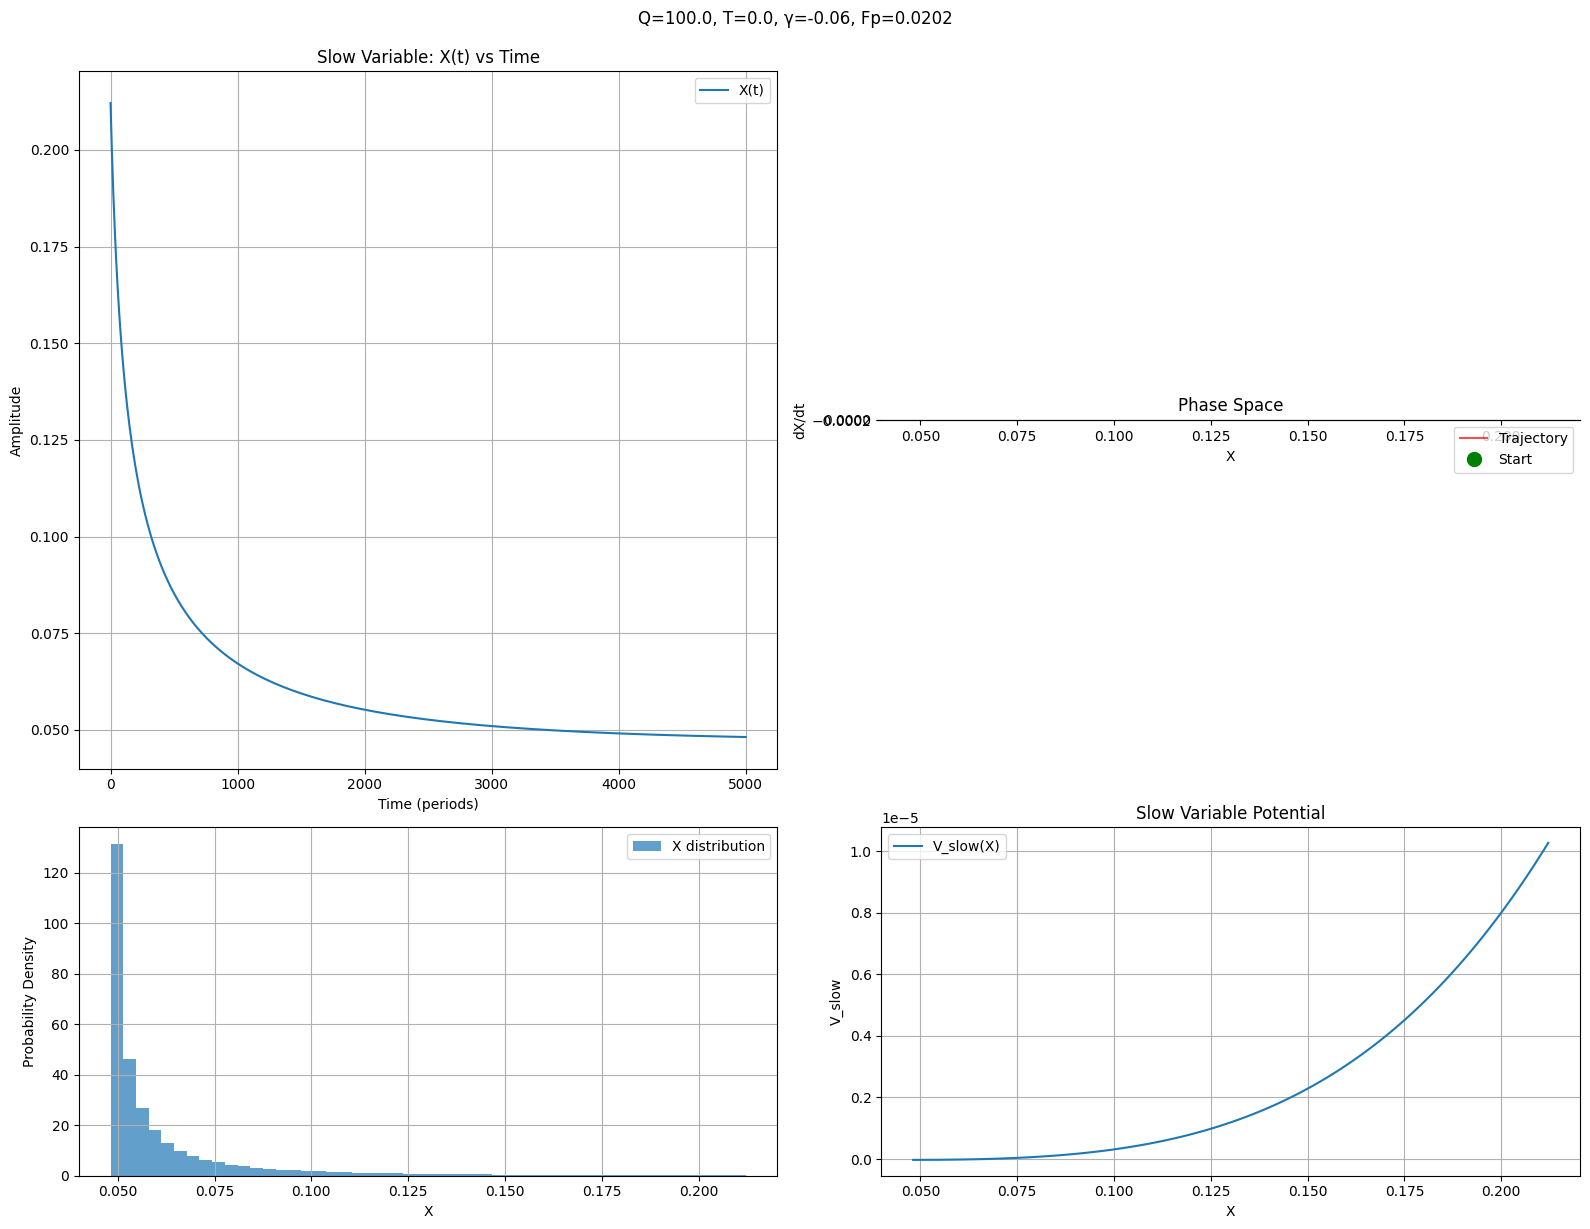

In [12]:
# Create figure with a grid of subplots
fig = plt.figure(figsize=(16, 12))
gs = plt.GridSpec(2, 2, height_ratios=[2, 1])

# Top left: X(t) trajectory
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ts_dim[:cutoff_idx]/period, sde_samples_X_slow[:cutoff_idx, 0], label='X(t)')
ax1.set_xlabel('Time (periods)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Slow Variable: X(t) vs Time')
ax1.grid(True)
ax1.legend()

# Top right: X vs dX/dt phase space
dXdt = jnp.gradient(sde_samples_X_slow[:, 0], ts_dim)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(sde_samples_X_slow[:, 0], dXdt, 'r-', label='Trajectory', alpha=0.7)
ax2.plot(sde_samples_X_slow[0, 0], dXdt[0], 'go', label='Start', markersize=10)
ax2.set_aspect('equal')
ax2.set_xlabel('X')
ax2.set_ylabel('dX/dt')
ax2.set_title('Phase Space')
ax2.grid(True)
ax2.legend()

# Bottom left: X histogram
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(sde_samples_X_slow[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax3.set_xlabel('X')
ax3.set_ylabel('Probability Density')
ax3.grid(True)
ax3.legend()

# Bottom right: Slow potential
X_range = jnp.linspace(min(sde_samples_X_slow[:, 0]), max(sde_samples_X_slow[:, 0]), 100)
V_slow = jnp.array([Potential_slow_var(x) for x in X_range])
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(X_range, V_slow, label='V_slow(X)')
ax4.set_xlabel('X')
ax4.set_ylabel('V_slow')
ax4.set_title('Slow Variable Potential')
ax4.grid(True)
ax4.legend()

plt.tight_layout()
# Add title with parameters
title = f'Q={Qual}, T={T}, γ={gamma}, Fp={F_p}'
plt.suptitle(title, y=1.02)

plt.show()

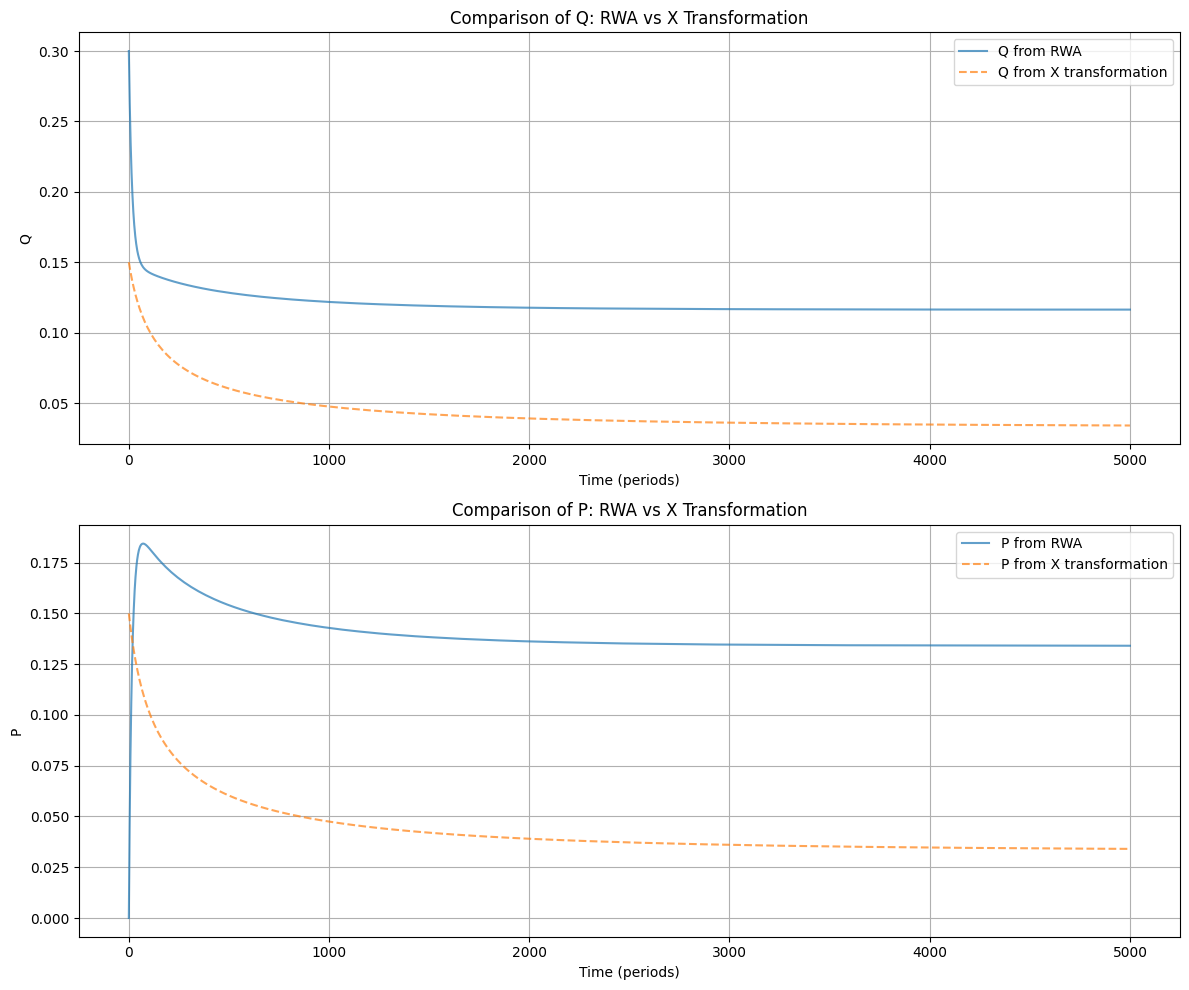

Alpha: 0.7854 radians (45.00 degrees)

RMS differences:
Q: 0.077330
P: 0.096795


In [13]:


# Transform X into Q and P components
X_to_Q = sde_samples_X_slow[:, 0] * jnp.cos(alpha)
X_to_P = sde_samples_X_slow[:, 0] * jnp.sin(alpha)

# Create comparison plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot Q comparison
ax1.plot(ts_dim[:cutoff_idx]/period, sde_samples_QP[:cutoff_idx, 0], 
         label='Q from RWA', alpha=0.7)
ax1.plot(ts_dim[:cutoff_idx]/period, X_to_Q[:cutoff_idx], 
         '--', label='Q from X transformation', alpha=0.7)
ax1.set_xlabel('Time (periods)')
ax1.set_ylabel('Q')
ax1.set_title('Comparison of Q: RWA vs X Transformation')
ax1.grid(True)
ax1.legend()

# Plot P comparison
ax2.plot(ts_dim[:cutoff_idx]/period, sde_samples_QP[:cutoff_idx, 1], 
         label='P from RWA', alpha=0.7)
ax2.plot(ts_dim[:cutoff_idx]/period, X_to_P[:cutoff_idx], 
         '--', label='P from X transformation', alpha=0.7)
ax2.set_xlabel('Time (periods)')
ax2.set_ylabel('P')
ax2.set_title('Comparison of P: RWA vs X Transformation')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

# Print the calculated alpha and some statistics
print(f"Alpha: {alpha:.4f} radians ({alpha*180/jnp.pi:.2f} degrees)")
print("\nRMS differences:")
print(f"Q: {jnp.sqrt(jnp.mean((sde_samples_QP[:, 0] - X_to_Q)**2)):.6f}")
print(f"P: {jnp.sqrt(jnp.mean((sde_samples_QP[:, 1] - X_to_P)**2)):.6f}")

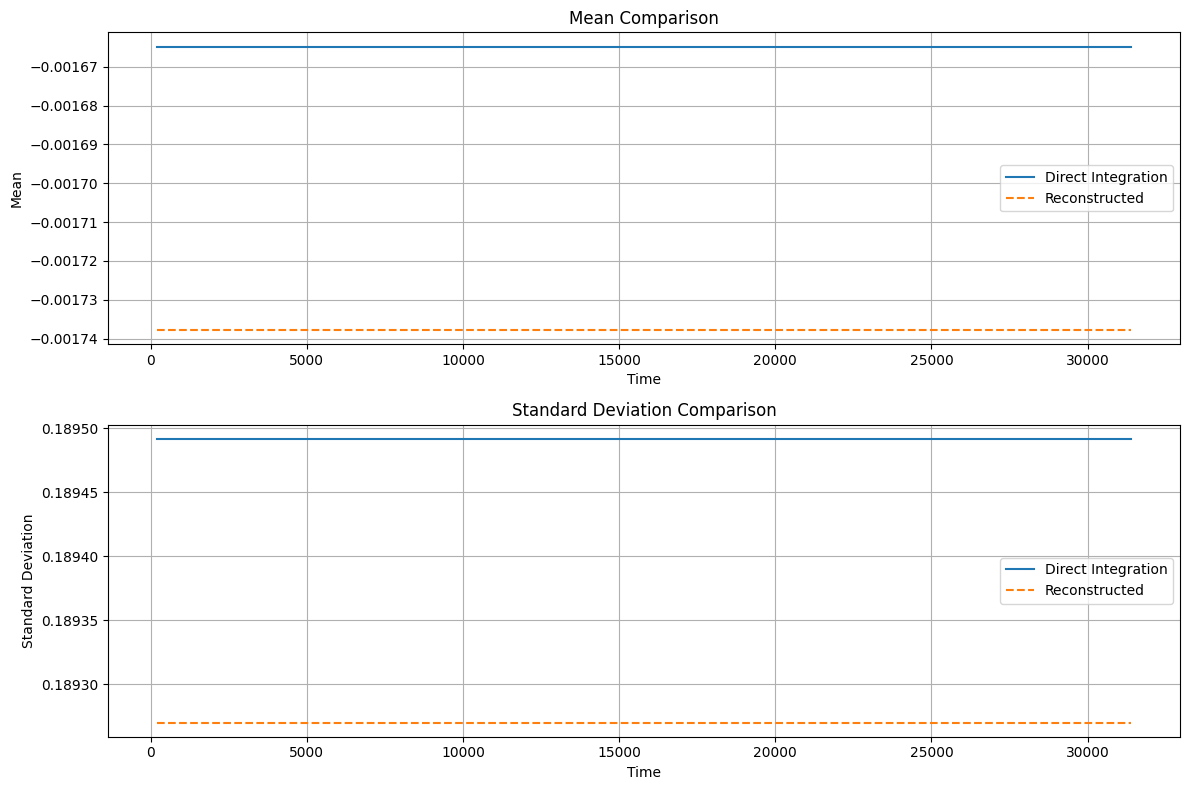

In [14]:
# After the reconstruction plot, add:

mean_direct = []
std_direct = []
mean_reconstructed = []
std_reconstructed = []
# Calculate step size based on w_0 and Q
relaxation_time = 2 * Qual / w_0
dt = ts_dim[1] - ts_dim[0]  # time step in the simulation
step = int(relaxation_time / dt)

for i in range(0, len(ts_dim), step):
    # Compute statistics
    mean_direct.append(jnp.mean(x_direct[:i]))
    std_direct.append(jnp.std(x_direct[:i]))
    mean_reconstructed.append(jnp.mean(x_reconstructed[:i]))
    std_reconstructed.append(jnp.std(x_reconstructed[:i]))

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot means
ax1.plot(ts_dim[::step], mean_direct, label='Direct Integration')
ax1.plot(ts_dim[::step], mean_reconstructed, '--', label='Reconstructed')
ax1.set_xlabel('Time')
ax1.set_ylabel('Mean')
ax1.set_title('Mean Comparison')
ax1.grid(True)
ax1.legend()

# Plot standard deviations
ax2.plot(ts_dim[::step], std_direct, label='Direct Integration')
ax2.plot(ts_dim[::step], std_reconstructed, '--', label='Reconstructed')
# Add horizontal line at 2kbT
# ax2.axhline(y=jnp.sqrt(k_B*T/M), color='r', linestyle=':', label='√(2kbT/mω₀²)')
ax2.set_xlabel('Time')
ax2.set_ylabel('Standard Deviation')
ax2.set_title('Standard Deviation Comparison')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

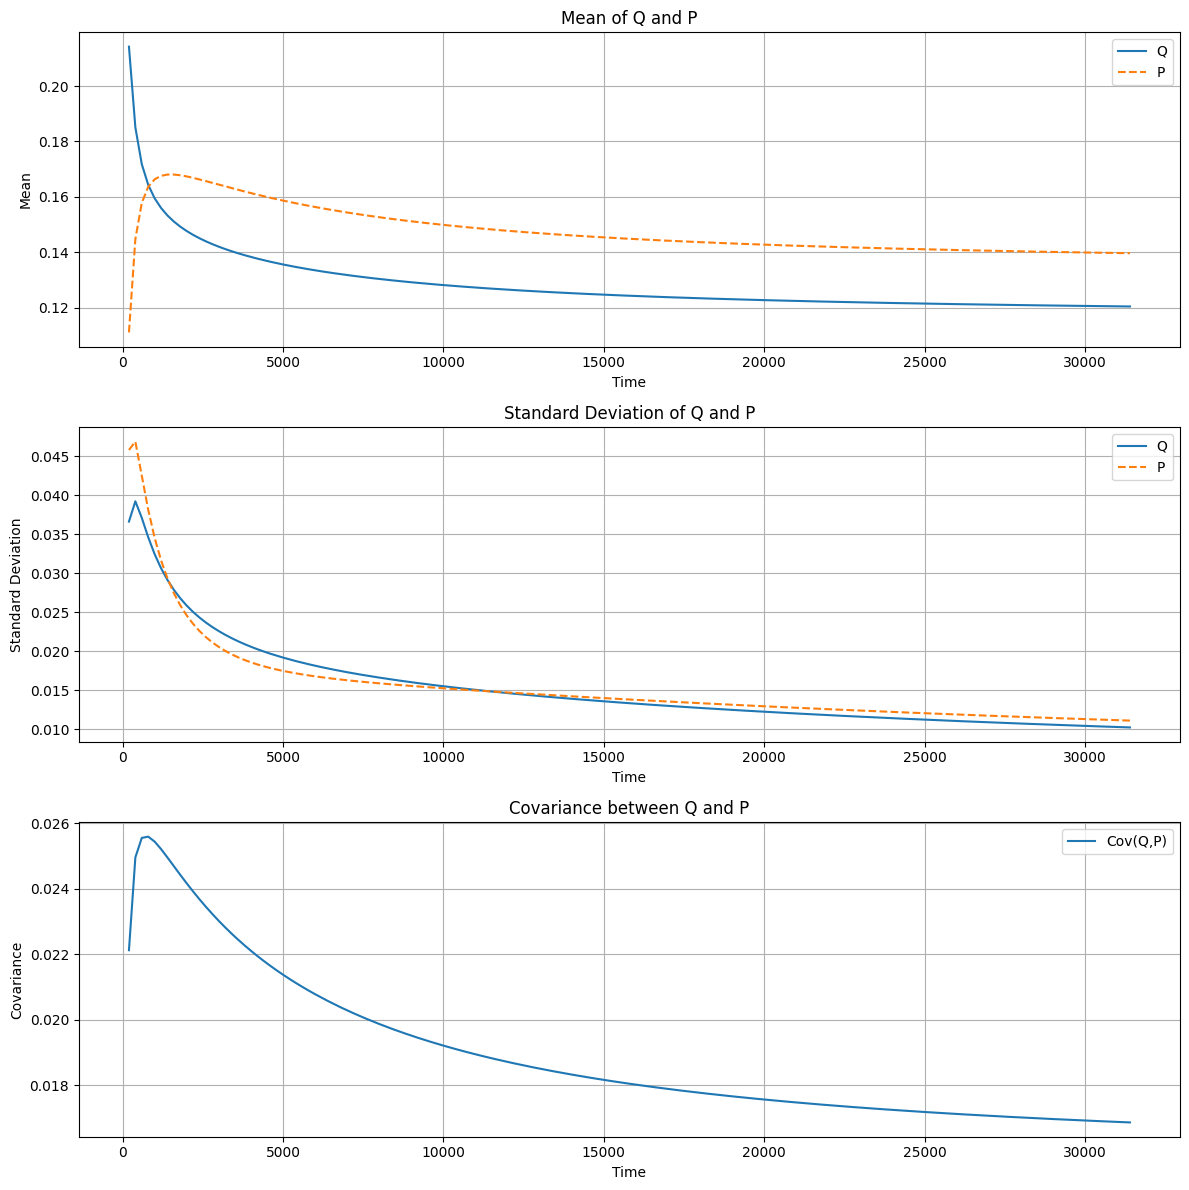

In [15]:
# Compute statistics for Q and P
mean_Q = []
mean_P = []
std_Q = []
std_P = []
cov_QP = []

for i in range(0, len(ts_dim), step):
    # Compute means and standard deviations
    mean_Q.append(jnp.mean(sde_samples_QP[:i, 0]))
    mean_P.append(jnp.mean(sde_samples_QP[:i, 1]))
    std_Q.append(jnp.std(sde_samples_QP[:i, 0]))
    std_P.append(jnp.std(sde_samples_QP[:i, 1]))
    # Compute covariance
    cov_QP.append(jnp.mean(sde_samples_QP[:i, 0] * sde_samples_QP[:i, 1]))

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))

# Plot means
ax1.plot(ts_dim[::step], mean_Q, label='Q')
ax1.plot(ts_dim[::step], mean_P, '--', label='P')
ax1.set_xlabel('Time')
ax1.set_ylabel('Mean')
ax1.set_title('Mean of Q and P')
ax1.grid(True)
ax1.legend()

# Plot standard deviations
ax2.plot(ts_dim[::step], std_Q, label='Q')
ax2.plot(ts_dim[::step], std_P, '--', label='P')
# Add horizontal line at theoretical value
theoretical_std = jnp.sqrt(k_B*T/(M*w_0**2))
ax2.set_xlabel('Time')
ax2.set_ylabel('Standard Deviation')
ax2.set_title('Standard Deviation of Q and P')
ax2.grid(True)
ax2.legend()

# Plot covariance
ax3.plot(ts_dim[::step], cov_QP, label='Cov(Q,P)')
ax3.set_xlabel('Time')
ax3.set_ylabel('Covariance')
ax3.set_title('Covariance between Q and P')
ax3.grid(True)
ax3.legend()

plt.tight_layout()
plt.show()